In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import warnings
warnings.filterwarnings('ignore')

print("Libraries loaded successfully!")

Libraries loaded successfully!


In [2]:
# Update the path if you named your file differently
data_path = '../data/raw/modis/modis_sample.csv'

try:
    df = pd.read_csv(data_path)
    print(f"Dataset shape: {df.shape}")
    display(df.head())
except FileNotFoundError:
    print(f"Could not find the file at {data_path}. Make sure you downloaded the CSV and placed it in the right folder!")

Dataset shape: (12486, 14)


,latitude,longitude,brightness,scan,track,acq_date,acq_time,satellite,instrument,confidence,version,bright_t31,frp,daynight
0,26.60615,94.39596,301.19,1.17,1.08,2026-01-26,312,Terra,MODIS,45,6.1NRT,289.17,5.53,D
1,26.59675,94.39401,300.70,1.17,1.08,2026-01-26,312,Terra,MODIS,41,6.1NRT,289.20,5.26,D
2,26.51566,94.70940,305.06,1.22,1.10,2026-01-26,312,Terra,MODIS,60,6.1NRT,288.43,9.89,D
3,26.60126,93.25143,308.09,1.06,1.03,2026-01-26,312,Terra,MODIS,63,6.1NRT,290.57,8.74,D
4,24.35723,92.92335,303.28,1.08,1.04,2026-01-26,312,Terra,MODIS,55,6.1NRT,290.00,6.57,D


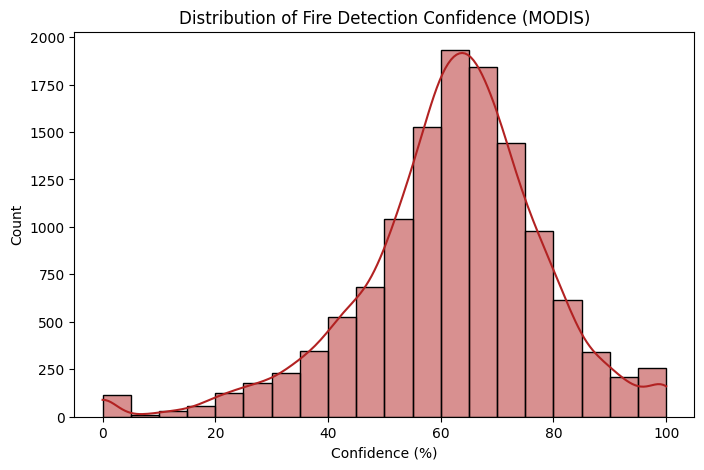

Number of high confidence fires: 1281


In [3]:
# Plot the distribution of detection confidence
plt.figure(figsize=(8, 5))
sns.histplot(df['confidence'], bins=20, kde=True, color='firebrick')
plt.title('Distribution of Fire Detection Confidence (MODIS)')
plt.xlabel('Confidence (%)')
plt.ylabel('Count')
plt.show()

# Filter for high confidence fires (e.g., > 80%)
high_conf_fires = df[df['confidence'] > 80]
print(f"Number of high confidence fires: {len(high_conf_fires)}")

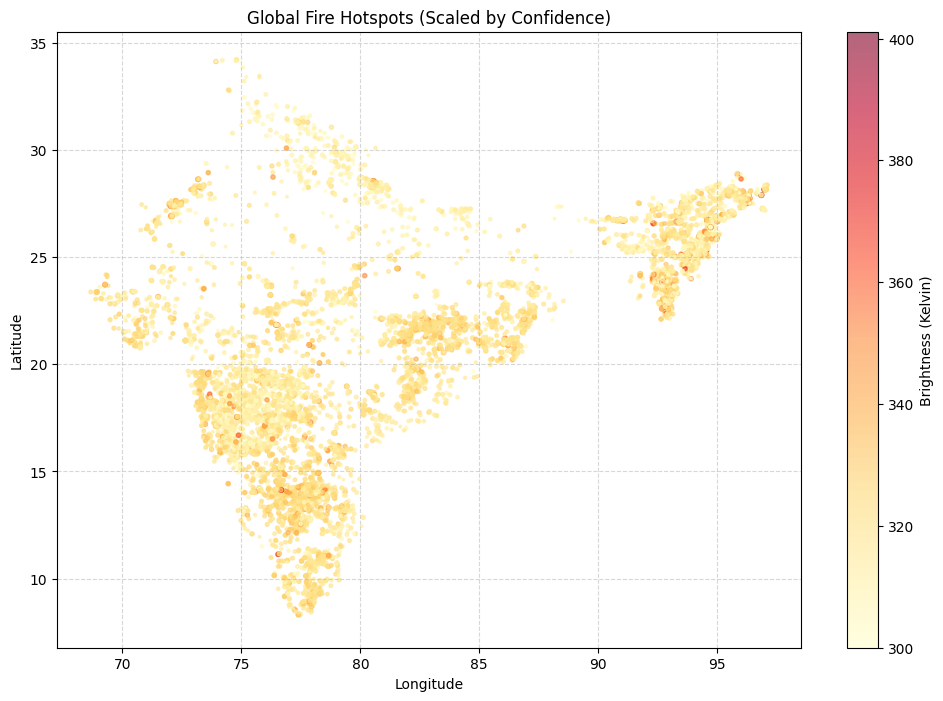

In [4]:
plt.figure(figsize=(12, 8))
plt.scatter(df['longitude'], df['latitude'], 
            c=df['brightness'], cmap='YlOrRd', 
            s=df['confidence']*0.1, alpha=0.6)

plt.colorbar(label='Brightness (Kelvin)')
plt.title('Global Fire Hotspots (Scaled by Confidence)')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()